# Team Baseline Analysis — LULC and LST (2020 vs 2025)

**Project:** Urban Heat Island — Dar es Salaam vs Singapore  
**Team:** Sharon · Monalisa · Aulia  
**Extended analysis:** Notebooks 03–08  

---

## What this notebook contains

This notebook consolidates the original work done by the project team:

- **Part 1 (Sharon + Aulia):** Land Use Land Cover change analysis using Dynamic World (10m, Sentinel-2)
- **Part 2 (Monalisa):** Land Surface Temperature analysis using MODIS (1km)

Both parts cover **2020 and 2025** for **Dar es Salaam** and **Singapore**.

### Changes from the original notebooks

| Change | Original | This notebook |
|---|---|---|
| GEE project | `g4g2023-wg` | `black-octagon-291810` |
| Cell [32] bug | `totalPixels_dar_2020` used for 2025 | Fixed to `totalPixels_dar_2025` |
| Cell [38] bug | Dar area used for Singapore check | Fixed to Singapore area |
| LST init | Empty project string `""` | Filled with `black-octagon-291810` |
| Structure | Two separate notebooks | One clean notebook, two parts |

### How this relates to the extended notebooks

```
This notebook (team baseline)
    │
    ├── Part 1: LULC 2020 vs 2025
    │       → Extended in:  03_lst_day_night_timeseries.ipynb (adds 2005-2015)
    │                       07_seasonal_breakdown.ipynb (adds dry/wet split)
    │
    └── Part 2: LST 2020 vs 2025 (MODIS)
            → Extended in:  04b_spectral_indices_patched.ipynb (adds Sentinel-2 correlation)
                            05_lcz_classification.ipynb (adds LCZ morphology)
                            06_synthesis_poster_figures.ipynb (synthesis)
```

## Setup — imports and GEE initialisation

In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# Initialise Earth Engine
# Change project ID if running on a different account
try:
    ee.Initialize(project='black-octagon-291810')
    print("Earth Engine initialised: black-octagon-291810")
except Exception:
    ee.Authenticate()
    ee.Initialize(project='black-octagon-291810')
    print("Earth Engine initialised after authentication")

# Sanity check
ee.Number(1).getInfo()
print("GEE round-trip confirmed")

Earth Engine initialised: black-octagon-291810
GEE round-trip confirmed


## Areas of Interest

Same boundaries used in all project notebooks — GAUL 2024 from the FAO/sat-io community dataset.

In [3]:
# Dar es Salaam — GAUL Level 1 (regional boundary)
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

# Singapore — GAUL Level 0 (country boundary)
aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

# Quick area check
def area_km2(geom):
    return geom.area(maxError=1).divide(1e6).getInfo()

print(f"Dar es Salaam AOI: {area_km2(dar_geom):.1f} sq km")
print(f"Singapore AOI:     {area_km2(sgp_geom):.1f} sq km")

Dar es Salaam AOI: 1622.9 sq km
Singapore AOI:     596.7 sq km


---

# PART 1: Land Use Land Cover (LULC) Analysis
### Sharon + Aulia

**Dataset:** Google Dynamic World V1  
**Resolution:** 10 metres (derived from Sentinel-2)  
**Years:** 2020 and 2025  
**Method:** Annual mode composite — the most frequently occurring land-cover class per pixel across all cloud-free Sentinel-2 scenes in each year

**9 Dynamic World classes:**

| Index | Class | Description |
|---|---|---|
| 0 | Water | Rivers, lakes, ocean |
| 1 | Trees | Forest, dense canopy |
| 2 | Grass | Open grass, lawns |
| 3 | Flooded vegetation | Mangroves, wetlands |
| 4 | Crops | Agriculture |
| 5 | Shrub and scrub | Low shrubs, bushland |
| 6 | **Built** | **Urban, roads, buildings** |
| 7 | Bare | Bare soil, sand, rock |
| 8 | Snow and ice | (not present in study area) |

### 1.1 Sentinel-2 imagery (visualisation only)

In [4]:
def get_sentinel2(geometry, year):
    """Return the least-cloudy Sentinel-2 scene for a given year and geometry."""
    start_date = f'{year}-01-01'
    end_date   = f'{year}-12-31'
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(geometry)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .sort('CLOUDY_PIXEL_PERCENTAGE'))
    return s2.first()

s2_dar_2020 = get_sentinel2(dar_geom, 2020)
s2_dar_2025 = get_sentinel2(dar_geom, 2025)
s2_sgp_2020 = get_sentinel2(sgp_geom, 2020)
s2_sgp_2025 = get_sentinel2(sgp_geom, 2025)

print("Sentinel-2 scenes loaded for visualisation")

Sentinel-2 scenes loaded for visualisation


### 1.2 Dynamic World mode composites

In [5]:
def get_mode_composite(year, geometry):
    """Annual mode composite of Dynamic World label band."""
    start_date = f'{year}-01-01'
    end_date   = f'{year}-12-31'
    collection = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
                    .filterBounds(geometry)
                    .filterDate(start_date, end_date)
                    .select('label'))
    return collection.reduce(ee.Reducer.mode()).rename('dw_mode').clip(geometry)

dwComposite_dar_2020 = get_mode_composite(2020, dar_geom)
dwComposite_dar_2025 = get_mode_composite(2025, dar_geom)
dwComposite_sgp_2020 = get_mode_composite(2020, sgp_geom)
dwComposite_sgp_2025 = get_mode_composite(2025, sgp_geom)

print("Dynamic World mode composites ready for 2020 and 2025")

Dynamic World mode composites ready for 2020 and 2025


### 1.3 Interactive map — Dynamic World LULC

In [6]:
DW_VIS = {
    'min': 0, 'max': 8,
    'palette': ['#419BDF','#397D49','#88B053','#7A87C6',
                '#E49635','#DFC35A','#C4281B','#A59B8F','#B39FE1']
}
CLASS_LABELS = ['water','trees','grass','flooded_vegetation','crops',
                'shrub_and_scrub','built','bare','snow_and_ice']
S2_VIS = {'bands':['B4','B3','B2'], 'min':0, 'max':3000}

Map = geemap.Map()
Map.addLayer(s2_dar_2020.clip(dar_geom),  S2_VIS, 'Dar S2 2020',  False)
Map.addLayer(s2_dar_2025.clip(dar_geom),  S2_VIS, 'Dar S2 2025',  False)
Map.addLayer(dwComposite_dar_2020, DW_VIS, 'Dar DW 2020')
Map.addLayer(dwComposite_dar_2025, DW_VIS, 'Dar DW 2025', False)
Map.addLayer(s2_sgp_2020.clip(sgp_geom),  S2_VIS, 'SGP S2 2020',  False)
Map.addLayer(s2_sgp_2025.clip(sgp_geom),  S2_VIS, 'SGP S2 2025',  False)
Map.addLayer(dwComposite_sgp_2020, DW_VIS, 'SGP DW 2020', False)
Map.addLayer(dwComposite_sgp_2025, DW_VIS, 'SGP DW 2025', False)
Map.centerObject(dar_geom, 10)
Map

Map(center=[-6.885315881886399, 39.261678578380916], controls=(WidgetControl(options=['position', 'transparent…

### 1.4 Built area statistics

**How the calculation works:**
1. Create a binary mask: pixels where DW class == 6 (built) get value 1, everything else 0
2. Count total pixels and built pixels using `reduceRegion`
3. Convert pixel count to area: each pixel = 10m × 10m = 100 m² = 0.0001 km²
4. Compute percentage = built pixels / total pixels × 100

In [7]:
PIXEL_AREA_KM2 = (10 * 10) / 1_000_000  # 10m resolution → km²

def get_built_stats(composite, geom, city, year):
    """Compute built-area count, area, and percentage."""
    built_mask = composite.eq(6).rename('built')
    counts = composite.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram().unweighted(),
        geometry=geom,
        scale=10,
        maxPixels=1e10,
    )
    built_px = ee.Number(
        ee.Dictionary(counts.get('dw_mode')).get('6', 0)
    ).getInfo()
    total_px = composite.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=geom,
        scale=10,
        maxPixels=1e10,
    ).get('dw_mode').getInfo()

    built_km2 = built_px * PIXEL_AREA_KM2
    total_km2 = total_px * PIXEL_AREA_KM2
    pct = 100 * built_px / total_px if total_px else 0

    print(f"  Built area in {city} ({year}): {built_km2:.2f} km²  "
          f"/ {total_km2:.2f} km² total  =  {pct:.2f}%")
    return {'city': city, 'year': year,
            'built_km2': built_km2, 'total_km2': total_km2, 'built_pct': pct}

print("=== BUILT AREA STATISTICS ===")
results = []
for composite, geom, city, year in [
    (dwComposite_dar_2020, dar_geom, 'Dar es Salaam', 2020),
    (dwComposite_dar_2025, dar_geom, 'Dar es Salaam', 2025),
    (dwComposite_sgp_2020, sgp_geom, 'Singapore',     2020),
    (dwComposite_sgp_2025, sgp_geom, 'Singapore',     2025),
]:
    results.append(get_built_stats(composite, geom, city, year))

built_df = pd.DataFrame(results)
print()
print(built_df.round(2).to_string(index=False))

=== BUILT AREA STATISTICS ===
  Built area in Dar es Salaam (2020): 945.88 km²  / 1631.40 km² total  =  57.98%
  Built area in Dar es Salaam (2025): 1007.95 km²  / 1638.36 km² total  =  61.52%
  Built area in Singapore (2020): 326.42 km²  / 586.10 km² total  =  55.69%
  Built area in Singapore (2025): 321.17 km²  / 596.10 km² total  =  53.88%

         city  year  built_km2  total_km2  built_pct
Dar es Salaam  2020     945.88    1631.40      57.98
Dar es Salaam  2025    1007.95    1638.36      61.52
    Singapore  2020     326.42     586.10      55.69
    Singapore  2025     321.17     596.10      53.88


### 1.5 All LULC class statistics

Compute area and percentage for all 9 Dynamic World classes in each city × year.

In [10]:
def get_lulc_stats(composite, geom, city, year):
    """Compute area and percentage for all 9 DW classes."""
    counts = composite.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram().unweighted(),
        geometry=geom,
        scale=10,
        maxPixels=1e10,
    ).get('dw_mode').getInfo()

    total_px = sum(counts.values())
    rows = []
    for idx, label in enumerate(CLASS_LABELS):
        px = counts.get(str(idx), 0)
        rows.append({
            'city': city, 'year': year, 'class': label,
            'pixels': px,
            'area_km2': px * PIXEL_AREA_KM2,
            'pct': 100 * px / total_px if total_px else 0,
        })
    return rows

print("Computing LULC statistics for all classes...")
all_rows = []
for composite, geom, city, year in [
    (dwComposite_dar_2020, dar_geom, 'Dar es Salaam', 2020),
    (dwComposite_dar_2025, dar_geom, 'Dar es Salaam', 2025),
    (dwComposite_sgp_2020, sgp_geom, 'Singapore',     2020),
    (dwComposite_sgp_2025, sgp_geom, 'Singapore',     2025),
]:
    print(f"  Processing {city} {year}...")
    all_rows.extend(get_lulc_stats(composite, geom, city, year))

lulc_df = pd.DataFrame(all_rows)

# Print summary tables
for city in ['Dar es Salaam', 'Singapore']:
    print(f"\n=== {city} ===")
    sub = lulc_df[lulc_df.city == city].pivot_table(
        index='class', columns='year', values='pct')
    sub['change_pp'] = sub[2025] - sub[2020]
    print(sub.round(2).sort_values('change_pp', ascending=False).to_string())

Computing LULC statistics for all classes...
  Processing Dar es Salaam 2020...
  Processing Dar es Salaam 2025...
  Processing Singapore 2020...
  Processing Singapore 2025...

=== Dar es Salaam ===
year                 2020   2025  change_pp
class                                      
built               57.73  61.52       3.79
shrub_and_scrub     15.34  16.33       0.99
bare                 0.55   0.79       0.24
snow_and_ice         0.01   0.01      -0.00
flooded_vegetation   0.65   0.57      -0.08
water                0.98   0.89      -0.09
crops                1.09   0.44      -0.65
grass                1.66   0.97      -0.70
trees               21.56  18.48      -3.08

=== Singapore ===
year                 2020   2025  change_pp
class                                      
trees               27.37  29.95       2.58
water                9.04  10.18       1.14
shrub_and_scrub      0.45   0.61       0.16
snow_and_ice         0.02   0.08       0.06
flooded_vegetation   0.09   0.03 

### 1.6 LULC composition bar chart — 2020 vs 2025

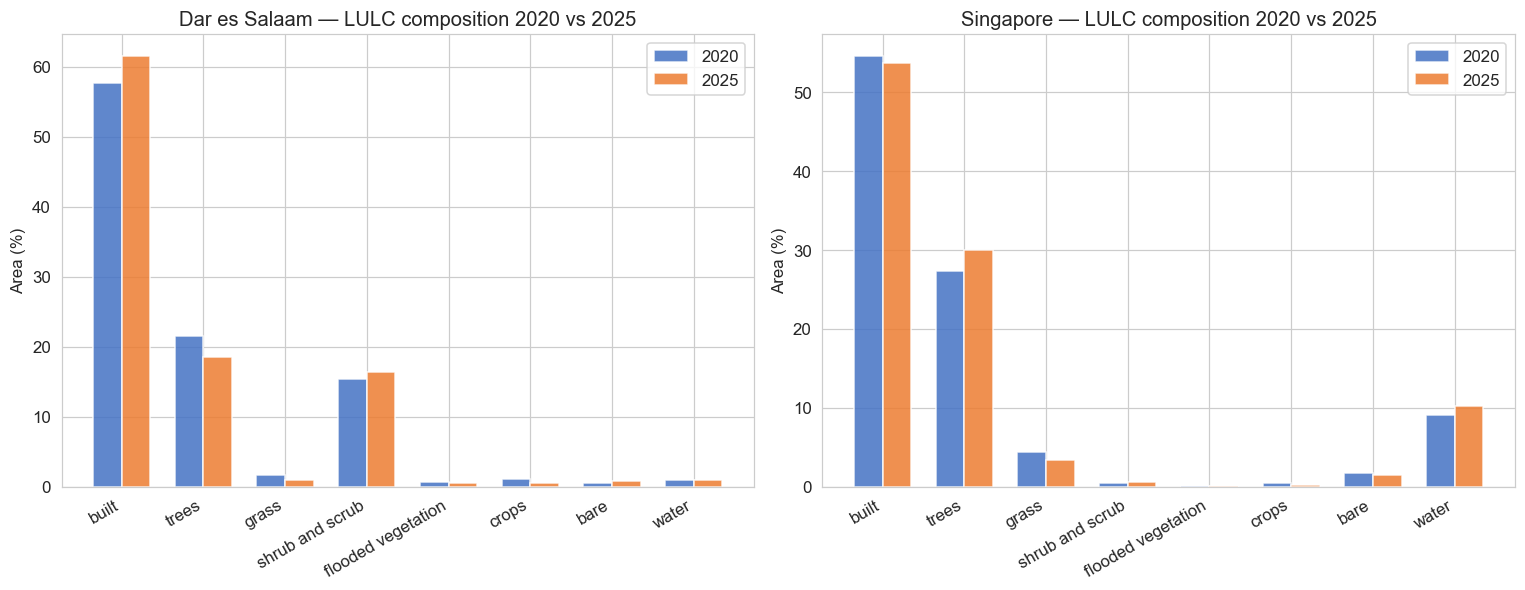

Saved: D:\uhi-dar-singapore\outputs\figures\team_lulc_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
focus_classes = ['built','trees','grass','shrub_and_scrub',
                 'flooded_vegetation','crops','bare','water']
colors_2020 = '#4472C4'
colors_2025 = '#ED7D31'

for ax, city in zip(axes, ['Dar es Salaam', 'Singapore']):
    sub = lulc_df[(lulc_df.city == city) &
                  (lulc_df['class'].isin(focus_classes))].copy()
    sub['class'] = pd.Categorical(sub['class'], categories=focus_classes, ordered=True)
    sub = sub.sort_values('class')
    x = range(len(focus_classes))
    w = 0.35
    v20 = sub[sub.year == 2020]['pct'].values
    v25 = sub[sub.year == 2025]['pct'].values
    bars20 = ax.bar([i - w/2 for i in x], v20, w, label='2020', color=colors_2020, alpha=0.85)
    bars25 = ax.bar([i + w/2 for i in x], v25, w, label='2025', color=colors_2025, alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels([c.replace('_',' ') for c in focus_classes], rotation=30, ha='right')
    ax.set_ylabel('Area (%)')
    ax.set_title(f'{city} — LULC composition 2020 vs 2025')
    ax.legend()

plt.tight_layout()
out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'team_lulc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / 'team_lulc_comparison.png').resolve()}")

### 1.7 LULC change chart — which classes grew and which shrank?

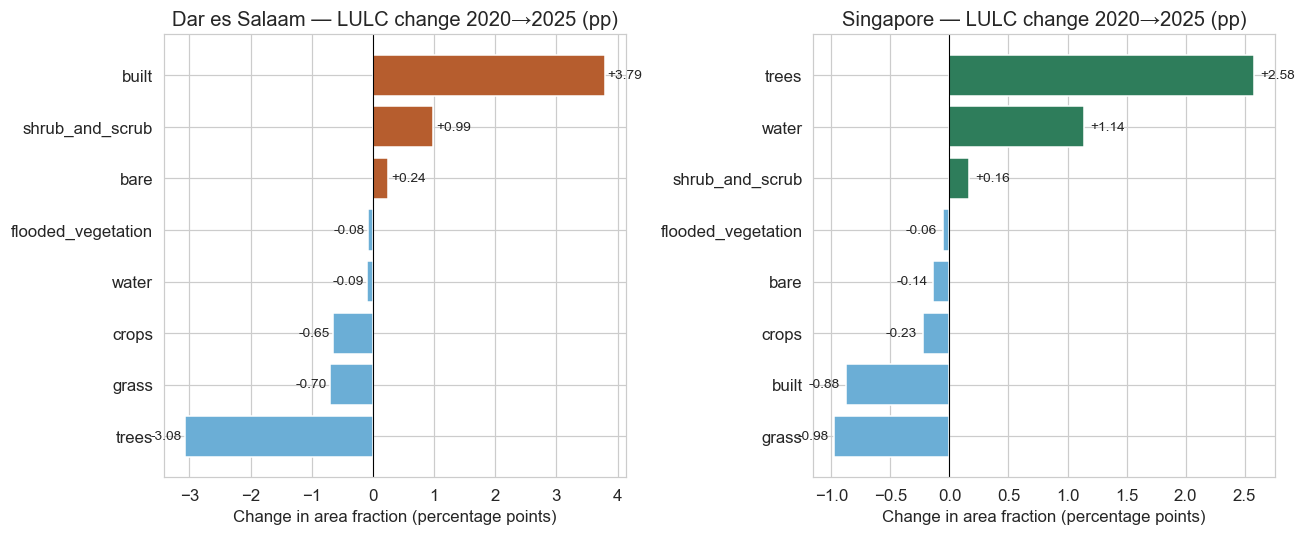

Saved: D:\uhi-dar-singapore\outputs\figures\team_lulc_change.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
CITY_COLORS = {'Dar es Salaam': '#B65D2E', 'Singapore': '#2E7D5B'}

for ax, city in zip(axes, ['Dar es Salaam', 'Singapore']):
    sub = lulc_df[lulc_df.city == city].pivot_table(
        index='class', columns='year', values='pct').reset_index()
    sub['change'] = sub[2025] - sub[2020]
    sub = sub[sub['class'].isin(focus_classes)].sort_values('change', ascending=True)
    bar_colors = [CITY_COLORS[city] if v > 0 else '#6baed6' for v in sub['change']]
    ax.barh(sub['class'], sub['change'], color=bar_colors)
    ax.axvline(0, color='black', lw=0.7)
    ax.set_title(f'{city} — LULC change 2020→2025 (pp)')
    ax.set_xlabel('Change in area fraction (percentage points)')
    for i, v in enumerate(sub['change']):
        ax.text(v + (0.05 if v >= 0 else -0.05), i, f'{v:+.2f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / 'team_lulc_change.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / 'team_lulc_change.png').resolve()}")

---

# PART 2: Land Surface Temperature (LST) Analysis
### Monalisa

**Dataset:** MODIS/061/MOD11A2 — Terra Land Surface Temperature, 8-day composites  
**Resolution:** 1 kilometre  
**Years:** 2020 and 2025  
**Method:**
1. Apply scale factor 0.02 to raw DN values
2. Convert Kelvin to Celsius (subtract 273.15)
3. Compute annual median from all 8-day composites (removes cloud artifacts)
4. Compare 2025 vs 2020 spatially and statistically

**UHI Intensity definition used:** pixel LST minus city-wide mean LST
(This is technically the UTFVI formulation — it shows which pixels are hotter or cooler than the city average)

### 2.1 MODIS LST pipeline — scale, convert, composite

In [13]:
def prepare_lst(image):
    """Apply MODIS scale factor (0.02) and convert Kelvin to Celsius."""
    return (image.select('LST_Day_1km')
                 .multiply(0.02)
                 .subtract(273.15)
                 .copyProperties(image, ['system:time_start']))

def get_annual_lst(geom, year):
    """Annual median daytime LST composite for a given year and geometry."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
             .filterBounds(geom)
             .filterDate(start, end)
             .map(prepare_lst))
    return col.median().clip(geom).rename('LST_Day_1km')

# Load 2020 and 2025 composites
lst_dar_2020 = get_annual_lst(dar_geom, 2020)
lst_dar_2025 = get_annual_lst(dar_geom, 2025)
lst_sgp_2020 = get_annual_lst(sgp_geom, 2020)
lst_sgp_2025 = get_annual_lst(sgp_geom, 2025)

print("MODIS LST composites loaded for 2020 and 2025")

# Quick mean check
for name, img, geom in [
    ('Dar 2020', lst_dar_2020, dar_geom),
    ('Dar 2025', lst_dar_2025, dar_geom),
    ('SGP 2020', lst_sgp_2020, sgp_geom),
    ('SGP 2025', lst_sgp_2025, sgp_geom),
]:
    mean = img.reduceRegion(ee.Reducer.mean(), geom, 1000,
                            maxPixels=1e9).get('LST_Day_1km').getInfo()
    print(f"  {name}: mean = {mean:.2f}°C")

MODIS LST composites loaded for 2020 and 2025
  Dar 2020: mean = 32.20°C
  Dar 2025: mean = 29.80°C
  SGP 2020: mean = 33.61°C
  SGP 2025: mean = 30.45°C


### 2.2 LST change 2020→2025

In [14]:
# LST change maps
dar_change = lst_dar_2025.subtract(lst_dar_2020).rename('LST_change')
sgp_change = lst_sgp_2025.subtract(lst_sgp_2020).rename('LST_change')

# Change statistics
for name, img, geom in [('Dar', dar_change, dar_geom), ('SGP', sgp_change, sgp_geom)]:
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True),
        geometry=geom, scale=1000, maxPixels=1e9
    ).getInfo()
    print(f"{name} change 2020→2025: mean={stats.get('LST_change_mean',stats.get('mean')):.3f}°C  "
          f"min={stats.get('LST_change_min',stats.get('min')):.2f}°C  "
          f"max={stats.get('LST_change_max',stats.get('max')):.2f}°C")

Dar change 2020→2025: mean=-2.398°C  min=-6.29°C  max=0.94°C
SGP change 2020→2025: mean=-3.159°C  min=-6.14°C  max=0.22°C


### 2.3 UHI Intensity

**Definition:** UHI Intensity = pixel LST − city-wide mean LST

A positive value means that pixel is hotter than the city average. A negative value means cooler. This identifies hotspots within each city.

In [15]:
def compute_uhi_intensity(lst_img, geom):
    """UHI intensity = pixel LST minus city mean LST."""
    city_mean = lst_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=1000,
        maxPixels=1e9
    ).get('LST_Day_1km')
    return lst_img.subtract(ee.Number(city_mean)).rename('UHI_intensity')

uhi_dar_2025 = compute_uhi_intensity(lst_dar_2025, dar_geom)
uhi_sgp_2025 = compute_uhi_intensity(lst_sgp_2025, sgp_geom)
uhi_dar_2020 = compute_uhi_intensity(lst_dar_2020, dar_geom)
uhi_sgp_2020 = compute_uhi_intensity(lst_sgp_2020, sgp_geom)

print("UHI intensity computed for 2020 and 2025")

UHI intensity computed for 2020 and 2025


### 2.4 Comparative statistics — UHI intensity and thermal spread

In [16]:
def get_stats(uhi_img, lst_img, geom, city, year):
    """Compute max UHI intensity, std dev, thermal spread."""
    max_uhi = uhi_img.reduceRegion(
        reducer=ee.Reducer.max(), geometry=geom, scale=1000, maxPixels=1e9
    ).get('UHI_intensity').getInfo()

    std_dev = uhi_img.reduceRegion(
        reducer=ee.Reducer.stdDev(), geometry=geom, scale=1000, maxPixels=1e9
    ).get('UHI_intensity').getInfo()

    lst_range = lst_img.reduceRegion(
        reducer=ee.Reducer.minMax(), geometry=geom, scale=1000, maxPixels=1e9
    ).getInfo()
    spread = lst_range.get('LST_Day_1km_max',0) - lst_range.get('LST_Day_1km_min',0)

    return {'city': city, 'year': year,
            'max_uhi_intensity': max_uhi,
            'std_dev': std_dev,
            'thermal_spread': spread}

print("=== COMPARATIVE STATISTICS ===")
stat_rows = []
for uhi, lst, geom, city, year in [
    (uhi_dar_2020, lst_dar_2020, dar_geom, 'Dar es Salaam', 2020),
    (uhi_dar_2025, lst_dar_2025, dar_geom, 'Dar es Salaam', 2025),
    (uhi_sgp_2020, lst_sgp_2020, sgp_geom, 'Singapore',     2020),
    (uhi_sgp_2025, lst_sgp_2025, sgp_geom, 'Singapore',     2025),
]:
    row = get_stats(uhi, lst, geom, city, year)
    stat_rows.append(row)
    print(f"  {city} {year}: max UHI={row['max_uhi_intensity']:.2f}°C  "
          f"std={row['std_dev']:.2f}°C  spread={row['thermal_spread']:.2f}°C")

stats_df = pd.DataFrame(stat_rows)
print()
print(stats_df.round(3).to_string(index=False))

=== COMPARATIVE STATISTICS ===
  Dar es Salaam 2020: max UHI=7.58°C  std=1.64°C  spread=12.49°C
  Dar es Salaam 2025: max UHI=4.57°C  std=1.32°C  spread=8.28°C
  Singapore 2020: max UHI=6.44°C  std=2.74°C  spread=12.58°C
  Singapore 2025: max UHI=4.25°C  std=1.70°C  spread=7.96°C

         city  year  max_uhi_intensity  std_dev  thermal_spread
Dar es Salaam  2020              7.584    1.637           12.49
Dar es Salaam  2025              4.572    1.322            8.28
    Singapore  2020              6.442    2.738           12.58
    Singapore  2025              4.253    1.703            7.96


### 2.5 Interactive map — LST and UHI

In [21]:
lst_vis = {
    'min': 22, 'max': 42,
    'palette': ['#2C7BB6','#ABD9E9','#FFFFBF','#FDAE61','#D7191C']
}
uhi_vis = {
    'min': -4, 'max': 4,
    'palette': ['#2166AC','#92C5DE','#F7F7F7','#F4A582','#D6604D']
}
change_vis = {
    'min': -3, 'max': 3,
    'palette': ['#2166AC','#92C5DE','#F7F7F7','#F4A582','#D6604D']
}

Map2 = geemap.Map()
Map2.addLayer(lst_dar_2020,   lst_vis,    'Dar LST 2020', False)
Map2.addLayer(lst_dar_2025,   lst_vis,    'Dar LST 2025')
Map2.addLayer(dar_change,     change_vis, 'Dar LST change 2020→2025', False)
Map2.addLayer(uhi_dar_2025,   uhi_vis,    'Dar UHI intensity 2025', False)
Map2.addLayer(lst_sgp_2020,   lst_vis,    'SGP LST 2020', False)
Map2.addLayer(lst_sgp_2025,   lst_vis,    'SGP LST 2025', False)
Map2.addLayer(sgp_change,     change_vis, 'SGP LST change 2020→2025', False)
Map2.addLayer(uhi_sgp_2025,   uhi_vis,    'SGP UHI intensity 2025', False)
Map2.centerObject(dar_geom, 10)
Map2

Map(center=[-6.885315881886399, 39.261678578380916], controls=(WidgetControl(options=['position', 'transparent…

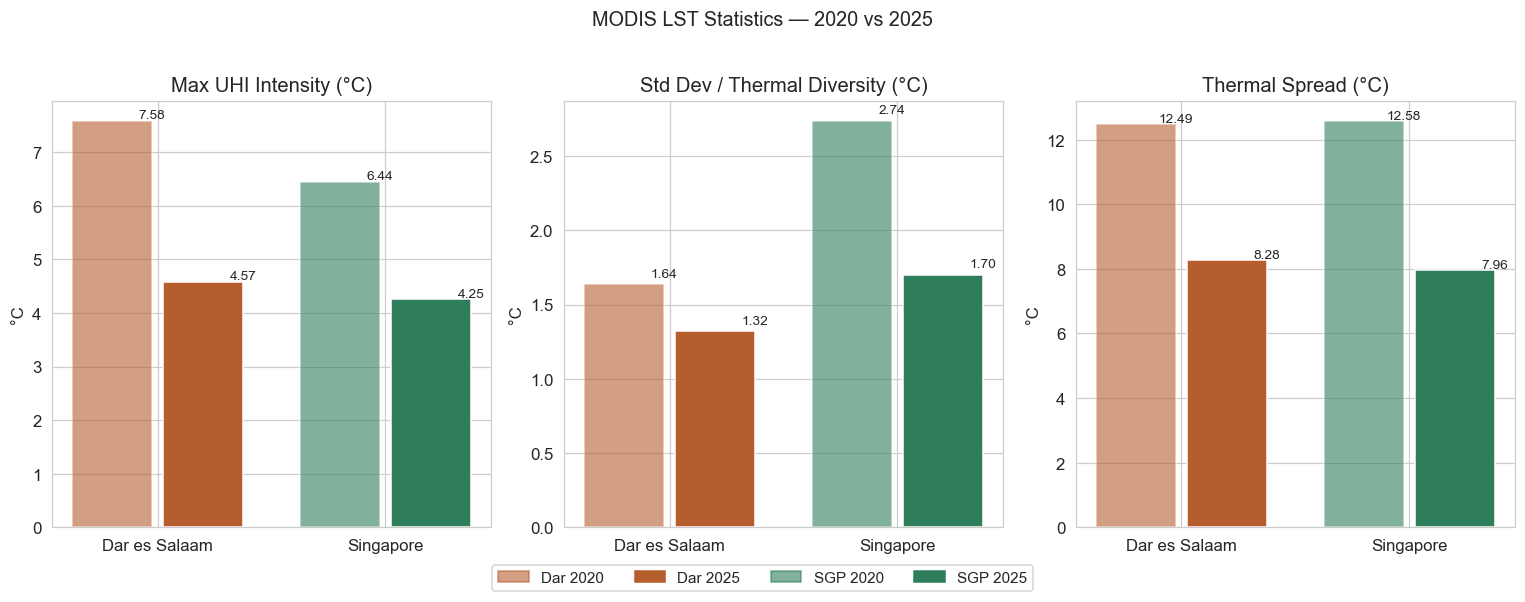

Saved: D:\uhi-dar-singapore\outputs\figures\team_lst_comparison.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics  = ['max_uhi_intensity', 'std_dev', 'thermal_spread']
titles   = ['Max UHI Intensity (°C)', 'Std Dev / Thermal Diversity (°C)', 'Thermal Spread (°C)']

for ax, metric, title in zip(axes, metrics, titles):
    x = [0, 0.4, 1.0, 1.4]
    vals = stats_df[metric].values
    colors = ['#B65D2E','#B65D2E','#2E7D5B','#2E7D5B']
    alphas = [0.6, 1.0, 0.6, 1.0]
    for xi, v, c, a in zip(x, vals, colors, alphas):
        ax.bar(xi, v, 0.35, color=c, alpha=a)
    ax.set_xticks([0.2, 1.2])
    ax.set_xticklabels(['Dar es Salaam', 'Singapore'])
    ax.set_title(title)
    ax.set_ylabel('°C')
    # Value labels
    for xi, v in zip(x, vals):
        ax.text(xi + 0.175, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# Shared legend
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='#B65D2E', alpha=0.6, label='Dar 2020'),
    mpatches.Patch(color='#B65D2E', alpha=1.0, label='Dar 2025'),
    mpatches.Patch(color='#2E7D5B', alpha=0.6, label='SGP 2020'),
    mpatches.Patch(color='#2E7D5B', alpha=1.0, label='SGP 2025'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('MODIS LST Statistics — 2020 vs 2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'team_lst_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / 'team_lst_comparison.png').resolve()}")

---

# PART 3: Combined Summary — LULC + LST, 2020 vs 2025

Bringing both analyses together into one summary table.

In [19]:
print("=" * 70)
print("PROJECT SUMMARY — Dar es Salaam vs Singapore, 2020 vs 2025")
print("=" * 70)

# LULC
for city in ['Dar es Salaam', 'Singapore']:
    sub = lulc_df[lulc_df.city == city]
    built_20 = sub[(sub.year==2020)&(sub['class']=='built')]['pct'].iloc[0]
    built_25 = sub[(sub.year==2025)&(sub['class']=='built')]['pct'].iloc[0]
    trees_20 = sub[(sub.year==2020)&(sub['class']=='trees')]['pct'].iloc[0]
    trees_25 = sub[(sub.year==2025)&(sub['class']=='trees')]['pct'].iloc[0]
    print(f"\n{city}:")
    print(f"  Built area:  {built_20:.2f}% (2020) → {built_25:.2f}% (2025)  Δ = {built_25-built_20:+.2f}pp")
    print(f"  Tree cover:  {trees_20:.2f}% (2020) → {trees_25:.2f}% (2025)  Δ = {trees_25-trees_20:+.2f}pp")

# LST
print()
for city in ['Dar es Salaam', 'Singapore']:
    rows = [r for r in stat_rows if r['city'] == city]
    r20 = [r for r in rows if r['year'] == 2020][0]
    r25 = [r for r in rows if r['year'] == 2025][0]
    print(f"{city}:")
    print(f"  Max UHI intensity:  {r20['max_uhi_intensity']:.2f}°C (2020) → {r25['max_uhi_intensity']:.2f}°C (2025)")
    print(f"  Std dev (diversity): {r20['std_dev']:.2f}°C (2020) → {r25['std_dev']:.2f}°C (2025)")
    print(f"  Thermal spread:     {r20['thermal_spread']:.2f}°C (2020) → {r25['thermal_spread']:.2f}°C (2025)")

PROJECT SUMMARY — Dar es Salaam vs Singapore, 2020 vs 2025

Dar es Salaam:
  Built area:  57.73% (2020) → 61.52% (2025)  Δ = +3.79pp
  Tree cover:  21.56% (2020) → 18.48% (2025)  Δ = -3.08pp

Singapore:
  Built area:  54.57% (2020) → 53.69% (2025)  Δ = -0.88pp
  Tree cover:  27.37% (2020) → 29.95% (2025)  Δ = +2.58pp

Dar es Salaam:
  Max UHI intensity:  7.58°C (2020) → 4.57°C (2025)
  Std dev (diversity): 1.64°C (2020) → 1.32°C (2025)
  Thermal spread:     12.49°C (2020) → 8.28°C (2025)
Singapore:
  Max UHI intensity:  6.44°C (2020) → 4.25°C (2025)
  Std dev (diversity): 2.74°C (2020) → 1.70°C (2025)
  Thermal spread:     12.58°C (2020) → 7.96°C (2025)


In [20]:
# Save LULC and stats to CSV
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

lulc_df.to_csv(out_tables / 'team_lulc_stats.csv', index=False)
stats_df.to_csv(out_tables / 'team_lst_stats.csv', index=False)

print("Saved:")
print(f"  {(out_tables / 'team_lulc_stats.csv').resolve()}")
print(f"  {(out_tables / 'team_lst_stats.csv').resolve()}")

Saved:
  D:\uhi-dar-singapore\outputs\tables\team_lulc_stats.csv
  D:\uhi-dar-singapore\outputs\tables\team_lst_stats.csv


---

## What's in this notebook vs the extended analysis notebooks

| Analysis | This notebook | Extended notebooks |
|---|---|---|
| LULC 2020 vs 2025 | ✅ Complete | 01 (original) |
| LST 2020 vs 2025 | ✅ Complete | 02 (original) |
| LST 2005–2025 trend | ❌ | 03_lst_day_night_timeseries |
| Nighttime LST | ❌ | 03_lst_day_night_timeseries |
| NDVI/NDBI correlation | ❌ | 04b_spectral_indices_patched |
| LCZ thermal analysis | ❌ | 05_lcz_classification |
| Poster figures | ❌ | 06_synthesis_poster_figures |
| Seasonal breakdown | ❌ | 07_seasonal_breakdown |
| Station validation | ❌ | 08_station_validation |

The extended notebooks build on the foundation laid here.
All use the same GEE project, same AOIs, same colour scheme.